In [20]:
import os
import json

# Konfigurasi kredensial dari file yang Anda upload
kaggle_creds = {"username":"nandaputrap","key":"2f969196f1cea4b311d518494c4a7615"}

# Menulis file ke lokasi yang dikenali sistem Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 600)

# Mengunduh dataset MNIST (menggunakan library keras karena lebih praktis untuk pemula)
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [21]:
# 1. LOAD DATASET
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

Loading MNIST dataset...


In [22]:
# 2. PREPROCESSING
# Mengubah dimensi (Flatten) dari 28x28 menjadi 784 untuk input MLP
x_train_flat = x_train.reshape((-1, 784)).astype('float32') / 255.0
x_test_flat = x_test.reshape((-1, 784)).astype('float32') / 255.0

In [23]:
# One-hot encoding untuk label
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

In [24]:
# 3. ARSITEKTUR MODEL MLP
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,), name='Hidden_Layer_1'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu', name='Hidden_Layer_2'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax', name='Output_Layer')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# 4. TRAINING
history = model.fit(x_train_flat, y_train_cat,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8341 - loss: 0.5461 - val_accuracy: 0.9606 - val_loss: 0.1297
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9611 - loss: 0.1269 - val_accuracy: 0.9722 - val_loss: 0.0905
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9743 - loss: 0.0813 - val_accuracy: 0.9723 - val_loss: 0.0867
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9804 - loss: 0.0629 - val_accuracy: 0.9746 - val_loss: 0.0853
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9841 - loss: 0.0503 - val_accuracy: 0.9747 - val_loss: 0.0858
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9866 - loss: 0.0400 - val_accuracy: 0.9787 - val_loss: 0.0758
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9779 - val_loss: 0.0866
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9898 - loss: 0.0308 - val_accu

In [26]:
# 5. EVALUASI
test_loss, test_acc = model.evaluate(x_test_flat, y_test_cat, verbose=0)
print(f"\nHasil Evaluasi - Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Hasil Evaluasi - Test Accuracy: 0.9805, Test Loss: 0.0693


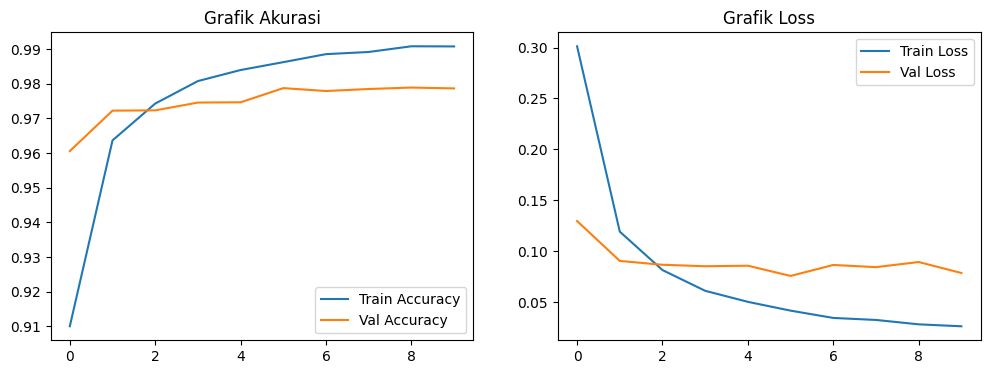

In [27]:
# Plot Akurasi dan Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Grafik Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


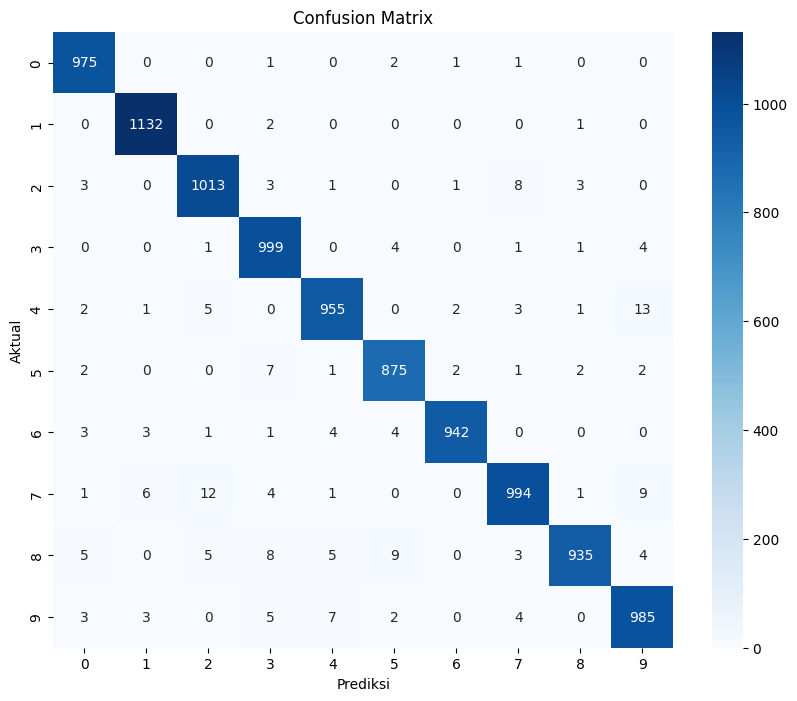

In [28]:
# 6. CONFUSION MATRIX
y_pred = np.argmax(model.predict(x_test_flat), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()